# E49 · Jumps: Bayesian jump-diffusion SDEs for the S&P 500

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | S&P 500 daily closes, May 2008 - November 2019 (2,905 daily log returns, via pymc-examples; the same series as C07 and E12) |
| **You will learn** | **Jump-diffusion SDEs**: Brownian motion plus a compound Poisson process, simulated exactly and with Euler steps · why the transition density is a **Poisson mixture of normals**, and how to write it in PyMC by summing out the jump count · the **Merton (1976)** model, and why with constant volatility it "finds" jumps on a third of all days · **stochastic volatility with jumps** (SVJ, in the spirit of Bates 1996 and Eraker, Johannes & Polson 2003): latent log-volatility (non-centred) plus a jump mixture · **posterior jump probabilities** per day, and why a jump is only a jump *relative to the current volatility* · comparing time-series models with **one-step-ahead predictive scores** from a **particle filter** (instead of LOO, which conditions on latent states) · decisions: the chance of a crash day in the next year, and the **volatility smile** a jump model implies for option prices |

## The question, in one paragraph

Most days the stock market moves a little, as if pushed by many small independent shocks -
that is the Brownian motion of textbook finance. But some days it falls off a cliff:
-9.5% on 15 October 2008, -6.9% on 8 August 2011, -4.1% on 5 February 2018. A model built
only from small shocks says such days should essentially never happen. Two ideas compete to
explain them: **jumps** (sudden discrete events: a surprise announcement, a flash crash) and
**changing volatility** (in a turbulent period, every day is shakier). The difference matters:
jumps cannot be hedged away by trading continuously, they make crash insurance expensive, and
they change how risk should be measured. This notebook writes both ideas as stochastic
differential equations, fits them to twelve years of S&P 500 data, and asks which days were
genuine jumps - and what that means for risk.

## The plan

1. A jump-diffusion SDE, simulated
2. The Merton model: jumps summed out
3. Stochastic volatility, with and without jumps
4. Which days were jumps?
5. Which model predicts best? One-step-ahead scores from a particle filter
6. Decisions: crash risk and the volatility smile

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy import optimize, stats
from scipy.special import logsumexp

from pymc_challenges import data

RANDOM_SEED = 49
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
MODEL_COLOURS = {"diffusion": GREY, "Merton": ORANGE, "SV": BLUE, "SVJ": RED}
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · A jump-diffusion SDE, simulated

Write $S_t$ for the index and $X_t = \log S_t$. The **Merton (1976) jump-diffusion** is

$$dX_t = \mu\,dt + \sigma\,dW_t + dJ_t, \qquad J_t = \sum_{i=1}^{N_t} Y_i,\quad
  N_t \sim \text{Poisson process with rate } \lambda,\quad Y_i \sim N(\mu_J, \sigma_J^2).$$

Between jumps the log price diffuses; at the random times of a Poisson process it jumps by a
random amount. Over one day ($\Delta t = 1$, rates per day) the number of jumps is
$N \sim \text{Poisson}(\lambda)$, and **given** $N = n$ the daily log return is exactly normal,
$N(\mu + n\mu_J,\ \sigma^2 + n\sigma_J^2)$. So the transition density is a **Poisson mixture of
normals**,

$$p(r) = \sum_{n=0}^{\infty} \frac{e^{-\lambda}\lambda^n}{n!}\;
  \phi\big(r;\ \mu + n\mu_J,\ \sigma^2 + n\sigma_J^2\big),$$

and its tails are much heavier than a normal's. To see what the SDE does we simulate it two
ways: exactly (Poisson count per day, then the conditional normal) and with a fine Euler scheme
(100 sub-steps per day, a Bernoulli jump in each), and compare with a pure diffusion of the same
daily variance.

daily sd: exact 0.946, Euler 0.946, theory 0.949
share of days below -4: jump-diffusion 0.0061, diffusion with the same variance 0.000010


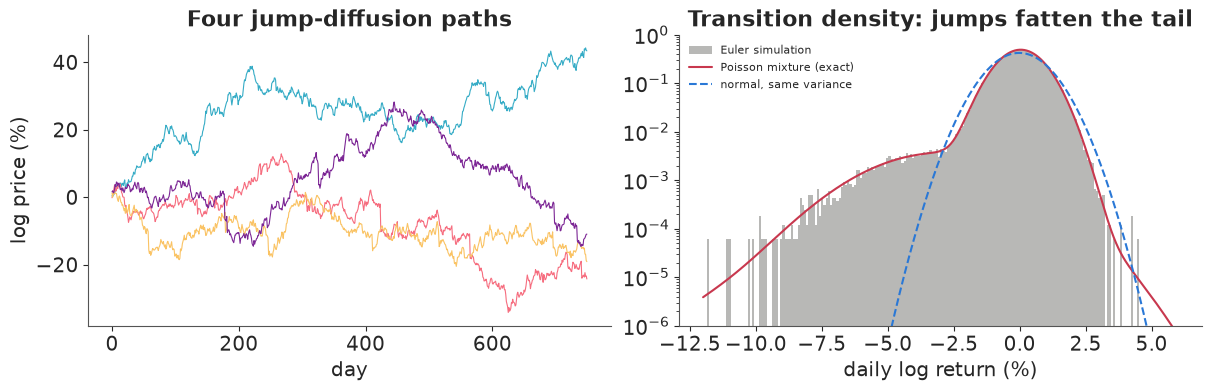

In [2]:
def simulate_merton(mu, sigma, lam, mu_j, sigma_j, days, rng, substeps=1):
    """Daily log returns of a Merton jump-diffusion (substeps > 1: Euler scheme)."""
    dt = 1.0 / substeps
    n = rng.poisson(lam * dt, size=(days, substeps))
    jumps = mu_j * n + sigma_j * np.sqrt(n) * rng.standard_normal((days, substeps))
    diff = mu * dt + sigma * np.sqrt(dt) * rng.standard_normal((days, substeps))
    return (diff + jumps).sum(axis=1)


demo = dict(mu=0.04, sigma=0.8, lam=0.02, mu_j=-3.0, sigma_j=2.0)   # one jump every ~50 days
sim_rng = np.random.default_rng(1)
r_exact = simulate_merton(**demo, days=200_000, rng=sim_rng)
r_euler = simulate_merton(**demo, days=200_000, rng=sim_rng, substeps=100)
var_total = demo["sigma"] ** 2 + demo["lam"] * (demo["sigma_j"] ** 2 + demo["mu_j"] ** 2)
r_gauss = sim_rng.normal(r_exact.mean(), np.sqrt(var_total), 200_000)
print(f"daily sd: exact {r_exact.std():.3f}, Euler {r_euler.std():.3f}, theory {np.sqrt(var_total):.3f}")
print(f"share of days below -4: jump-diffusion {np.mean(r_exact < -4):.4f}, "
      f"diffusion with the same variance {np.mean(r_gauss < -4):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
path_rng = np.random.default_rng(3)
for i in range(4):
    ax.plot(np.cumsum(simulate_merton(**demo, days=750, rng=path_rng)), lw=0.8)
ax.set(xlabel="day", ylabel="log price (%)", title="Four jump-diffusion paths")
ax = axes[1]
grid = np.linspace(-12, 6, 400)
n_terms = np.arange(8)
dens = (stats.poisson.pmf(n_terms, demo["lam"])[:, None]
        * stats.norm.pdf(grid, demo["mu"] + n_terms[:, None] * demo["mu_j"],
                         np.sqrt(demo["sigma"] ** 2 + n_terms[:, None] * demo["sigma_j"] ** 2))).sum(0)
ax.hist(r_euler, bins=200, density=True, color=GREY, alpha=0.6, label="Euler simulation")
ax.plot(grid, dens, color=RED, label="Poisson mixture (exact)")
ax.plot(grid, stats.norm.pdf(grid, r_exact.mean(), np.sqrt(var_total)), color=BLUE, ls="--",
        label="normal, same variance")
ax.set(yscale="log", ylim=(1e-6, 1), xlabel="daily log return (%)", title="Transition density: jumps fatten the tail")
ax.legend(fontsize=8);

The exact simulation, the Euler scheme and the formula agree. With the same overall variance, a
pure diffusion almost never produces a -4% day, while the jump-diffusion produces one every few
hundred days. On the log scale the mixture is a normal body with a heavy left shoulder: the
signature of jumps.

## 2 · The Merton model: jumps summed out

Now the data: daily log returns of the S&P 500 in per cent.

sp500: Daily close and log-return ('change').
  source: S&P 500 index daily closes (2008-2019), via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/SP500.csv
2905 daily returns, 2008-05-05 to 2019-11-14; sd 1.24%, min -9.47% (2008-10-15), max 10.96% (2008-10-13); excess kurtosis 11.6


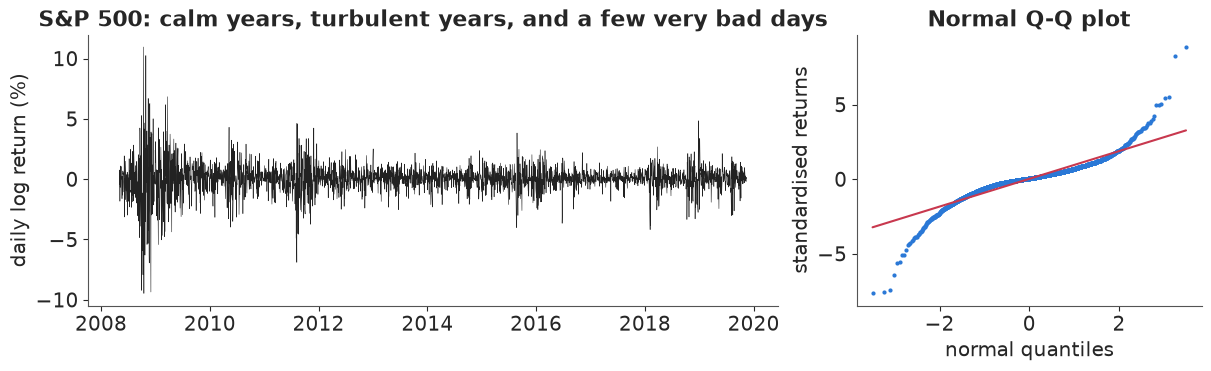

In [3]:
data.describe("sp500")
df = data.load("sp500")
r = 100 * np.diff(np.log(df["Close"].to_numpy()))
dates = pd.to_datetime(df.index[1:])
T = len(r)
print(f"{T} daily returns, {dates[0].date()} to {dates[-1].date()}; sd {r.std():.2f}%, "
      f"min {r.min():.2f}% ({dates[r.argmin()].date()}), max {r.max():.2f}% ({dates[r.argmax()].date()}); "
      f"excess kurtosis {stats.kurtosis(r):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(dates, r, color=INK, lw=0.4)
axes[0].set(ylabel="daily log return (%)", title="S&P 500: calm years, turbulent years, and a few very bad days")
stats.probplot(r / r.std(), dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=BLUE, markersize=2)
axes[1].get_lines()[1].set(color=RED)
axes[1].set(title="Normal Q-Q plot", xlabel="normal quantiles", ylabel="standardised returns");

Heavy tails (excess kurtosis far above 0, the Q-Q plot bending away at both ends) and obvious
**volatility clustering** (2008-09, 2011, 2015-16, early 2018 and late 2018 are turbulent). We fit the
Merton model first, with constant volatility. The likelihood sums the jump count out, up to 4
jumps per day (the Poisson weight of 5 jumps is negligible for any plausible $\lambda$). Priors,
in per cent per day: $\mu \sim N(0, 0.1)$, $\sigma \sim$ HalfNormal(1.5), the daily jump rate
$\lambda \sim$ Beta(1, 20) (a jump every 20 days on average a priori, but rare jumps allowed),
$\mu_J \sim N(0, 2)$, $\sigma_J \sim$ HalfNormal(4).

We store each day's log-likelihood and the posterior probability that the day contained a
jump, $P(N_t \ge 1 \mid r_t, \theta)$, as deterministics.

In [4]:
N_MAX = 4
n_jumps = np.arange(N_MAX + 1)

with pm.Model() as merton_model:
    mu = pm.Normal("mu", 0, 0.1)
    sigma = pm.HalfNormal("sigma", 1.5)
    lam = pm.Beta("lam", 1, 20)
    mu_j = pm.Normal("mu_j", 0, 2)
    sigma_j = pm.HalfNormal("sigma_j", 4)
    log_w = pm.logp(pm.Poisson.dist(lam), n_jumps)                                   # (N,)
    log_comp = log_w + pm.logp(pm.Normal.dist(mu + n_jumps * mu_j,
                                              pt.sqrt(sigma**2 + n_jumps * sigma_j**2)), r[:, None])
    loglik = pt.logsumexp(log_comp, axis=1)
    pm.Potential("likelihood", loglik.sum())
    pm.Deterministic("p_jump_day", 1 - pt.exp(log_comp[:, 0] - loglik))

t0 = time.time()
with merton_model:
    idata_merton = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"Merton: {time.time() - t0:.0f} s, {int(idata_merton.sample_stats['diverging'].sum())} divergences")
print(az.summary(idata_merton, var_names=["mu", "sigma", "lam", "mu_j", "sigma_j"], round_to=3)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])

Merton: 4 s, 0 divergences
          mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat
mu       0.113  0.015     0.088     0.138  2769.118  1.000
sigma    0.567  0.024     0.527     0.606  1241.197  1.001
lam      0.345  0.038     0.286     0.411  1175.872  1.001
mu_j    -0.256  0.070    -0.373    -0.146  2380.274  1.001
sigma_j  1.782  0.099     1.633     1.944  1370.580  1.001


The fit is clean, and the answer is odd. The daily jump rate $\lambda$ is about 0.34: **a jump
on one day in three**, with jump sizes of about ±1.8% and a small negative mean. With the
diffusion volatility at about 0.57% per day, the "jumps" are not rare discrete events - the
model is using them to make every day's distribution a mixture of a calm and a wild normal. That
is what the Merton model must do when volatility changes over time and the model has only one
$\sigma$: turbulent periods can only be explained by frequent jumps. The model is fitting the
heavy tails of the *marginal* distribution, and the "jumps" absorb the volatility clustering.

## 3 · Stochastic volatility, with and without jumps

The standard remedy is to let the volatility itself follow an SDE. In discrete time, the
**stochastic volatility (SV)** model makes the log-variance an AR(1) (an Ornstein-Uhlenbeck
process sampled daily):

$$r_t = \mu + e^{h_t/2}\,\varepsilon_t, \qquad h_t = \bar h + \phi\,(h_{t-1} - \bar h) + s_h\,\eta_t,$$

and **SVJ** adds a jump: with daily probability $p$, $r_t$ gets an extra $N(\mu_J, \sigma_J^2)$
(at most one jump per day, the usual discrete-time approximation when jumps are rare). The jump
indicator is summed out exactly as before, now with only two terms. Priors: $\bar h \sim N(0,
1)$, $\phi \sim$ Beta(20, 1.5) (volatility is persistent), $s_h \sim$ HalfNormal(0.3), $p \sim$
Beta(1, 50) (jumps rare a priori), and as before for the rest.

The latent $h_t$ is written **non-centred**: we sample standardised shocks $\eta_t$ and build
$h$ with `scan`. E46 warned against that for chaotic maps, but the AR(1) is stable ($|\phi| <
1$): errors shrink as they propagate, so the non-centred form is safe - and here it mixes much
better than the centred one (a first centred attempt gave $\hat R = 1.10$ and ESS below 80 for
$s_h$; C07 and E12 discuss this posterior at length).

In [5]:
def sv_model(jumps):
    with pm.Model() as model:
        mu = pm.Normal("mu", 0, 0.1)
        h_bar = pm.Normal("h_bar", 0, 1)
        phi = pm.Beta("phi", 20, 1.5)
        s_h = pm.HalfNormal("s_h", 0.3)
        eta = pm.Normal("eta", 0, 1, shape=T)
        h0 = h_bar + s_h / pt.sqrt(1 - phi**2) * eta[0]
        h_rest = pytensor.scan(lambda e, h_prev, hb, ph, s: hb + ph * (h_prev - hb) + s * e,
                               sequences=[eta[1:]], outputs_info=[h0],
                               non_sequences=[h_bar, phi, s_h], return_updates=False)
        h = pm.Deterministic("h", pt.concatenate([h0[None], h_rest]))
        vol = pt.exp(h / 2)
        if jumps:
            p = pm.Beta("p_jump", 1, 50)
            mu_j = pm.Normal("mu_j", 0, 2)
            sigma_j = pm.HalfNormal("sigma_j", 4)
            l0 = pt.log1p(-p) + pm.logp(pm.Normal.dist(mu, vol), r)
            l1 = pt.log(p) + pm.logp(pm.Normal.dist(mu + mu_j, pt.sqrt(vol**2 + sigma_j**2)), r)
            loglik = pt.logaddexp(l0, l1)
            pm.Deterministic("p_jump_day", pt.exp(l1 - loglik))
        else:
            loglik = pm.logp(pm.Normal.dist(mu, vol), r)
        pm.Potential("likelihood", loglik.sum())
    return model


fits = {"Merton": idata_merton}
for name, jumps in [("SV", False), ("SVJ", True)]:
    t0 = time.time()
    with sv_model(jumps):
        fits[name] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
    idata_x = fits[name]
    del idata_x.posterior["eta"]                         # keep h, drop the shocks (memory)
    names = [v for v in ["mu", "h_bar", "phi", "s_h", "p_jump", "mu_j", "sigma_j"] if v in idata_x.posterior]
    print(f"{name}: {time.time() - t0:.0f} s, {int(idata_x.sample_stats['diverging'].sum())} divergences")
    print(az.summary(idata_x, var_names=names, round_to=3)[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])

SV: 73 s, 0 divergences
        mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat
mu     0.085  0.012     0.066     0.105  7470.461  1.003
h_bar -0.433  0.207    -0.763    -0.103   704.460  1.003
phi    0.973  0.006     0.963     0.982   527.811  1.003
s_h    0.282  0.023     0.246     0.320   681.581  1.004


SVJ: 81 s, 0 divergences
          mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat
mu       0.098  0.013     0.078     0.120  4271.142  1.001
h_bar   -0.478  0.221    -0.824    -0.111   822.804  1.005
phi      0.978  0.005     0.969     0.986   497.170  1.004
s_h      0.255  0.022     0.220     0.291   540.580  1.005
p_jump   0.025  0.018     0.009     0.061   728.862  1.005
mu_j    -1.275  0.531    -1.909    -0.271   707.630  1.004
sigma_j  0.522  0.378     0.048     1.138   678.540  1.007


Both fit cleanly. Volatility is very persistent ($\phi \approx 0.97$-0.98: a shock to
volatility halves in about a month) and the volatility of volatility $s_h$ is about 0.26-0.28.
Once volatility can move, **the jumps become rare**: SVJ's daily jump probability is about
2.5% (roughly six jumps a year, with a wide posterior), and the jumps are modest, a mean of
about -1.3% with a small spread. They are not the 2008 crash days. The next section shows
which days they are.

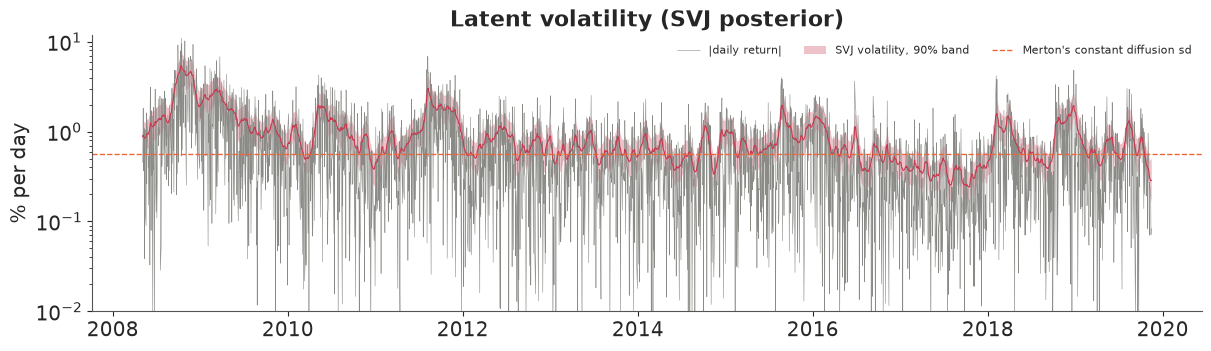

In [6]:
h_svj = fits["SVJ"].posterior["h"].mean(("chain", "draw")).to_numpy()
vol_q = np.quantile(np.exp(fits["SVJ"].posterior["h"].stack(sample=("chain", "draw")).to_numpy() / 2),
                    [0.05, 0.5, 0.95], axis=1)
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(dates, np.abs(r), color=GREY, lw=0.4, label="|daily return|")
ax.fill_between(dates, vol_q[0], vol_q[2], color=RED, alpha=0.3, lw=0, label="SVJ volatility, 90% band")
ax.plot(dates, vol_q[1], color=RED, lw=0.8)
ax.axhline(fits["Merton"].posterior["sigma"].mean().item(), color=ORANGE, ls="--", lw=1,
           label="Merton's constant diffusion sd")
ax.set(ylabel="% per day", yscale="log", ylim=(0.01, 12), title="Latent volatility (SVJ posterior)")
ax.legend(fontsize=8, ncols=3, loc="upper right");

## 4 · Which days were jumps?

Each model gives every day a posterior probability of containing a jump. Averaged over the
posterior, these are the models' verdicts; we list the largest moves of the period and the days
SVJ is most sure about.

The eight largest moves:
            return %  SVJ volatility %  return / volatility  P(jump) Merton  P(jump) SVJ
2008-10-13     10.96              5.46                 2.01             1.0         0.02
2008-10-28     10.25              4.77                 2.15             1.0         0.02
2008-10-15     -9.47              5.36                -1.77             1.0         0.04
2008-12-01     -9.35              4.28                -2.19             1.0         0.05
2008-09-29     -9.22              4.29                -2.15             1.0         0.05
2008-10-09     -7.92              5.17                -1.53             1.0         0.04
2008-11-20     -6.95              4.73                -1.47             1.0         0.04
2011-08-08     -6.90              3.04                -2.27             1.0         0.06

The eight days SVJ is most sure were jumps:
            return %  SVJ volatility %  return / volatility  P(jump) Merton  P(jump) SVJ
2017-05-17     -1.83              0.32  

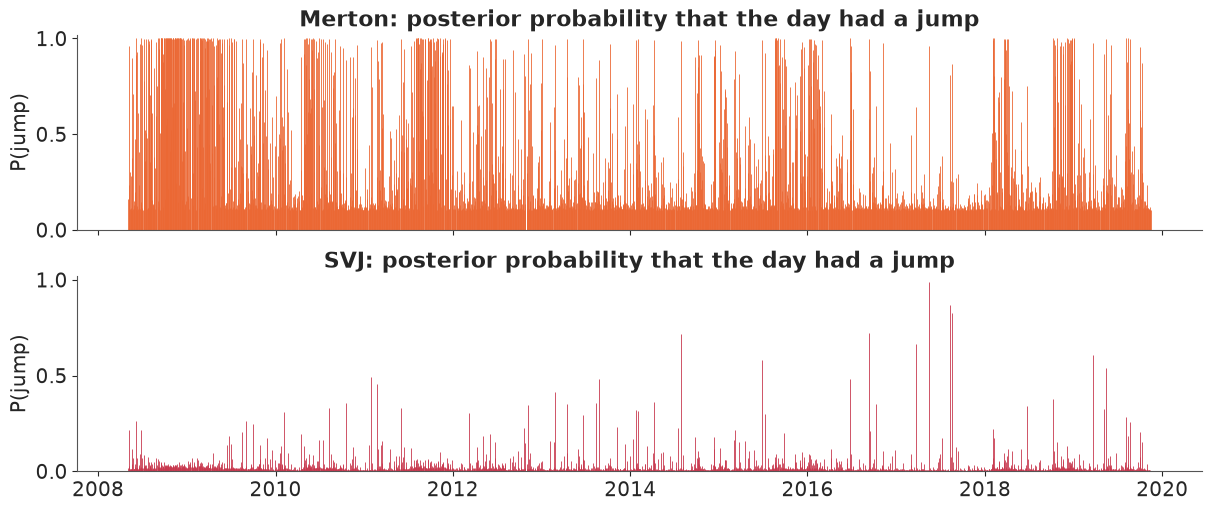

In [7]:
p_day = {name: fits[name].posterior["p_jump_day"].mean(("chain", "draw")).to_numpy()
         for name in ["Merton", "SVJ"]}
vol_svj = np.exp(h_svj / 2)
table = pd.DataFrame({"return %": r, "SVJ volatility %": vol_svj, "return / volatility": r / vol_svj,
                      "P(jump) Merton": p_day["Merton"], "P(jump) SVJ": p_day["SVJ"]},
                     index=dates.date)
print("The eight largest moves:")
print(table.iloc[np.argsort(-np.abs(r))[:8]].round(2).to_string())
print("\nThe eight days SVJ is most sure were jumps:")
print(table.iloc[np.argsort(-p_day["SVJ"])[:8]].round(2).to_string())
print(f"\nexpected number of jump days: Merton {p_day['Merton'].sum():.0f}, SVJ {p_day['SVJ'].sum():.0f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, name in zip(axes, ["Merton", "SVJ"]):
    ax.vlines(dates, 0, p_day[name], color=MODEL_COLOURS[name], lw=0.6)
    ax.set(ylabel="P(jump)", ylim=(0, 1.02), title=f"{name}: posterior probability that the day had a jump")
fig.align_ylabels();

The two models disagree completely, and the disagreement is the lesson. **Merton** calls the big
crash days jumps with certainty, and also a large share of all turbulent days in 2008-09 and
2011: in its world, any large move is a jump because volatility never changes. **SVJ** gives the
famous crash days *low* jump probabilities: on 15 October 2008 the market was already moving
4-6% a day, so a -9.5% day is about two standard deviations of *that day's* volatility - bad,
but not a discontinuity. SVJ's jumps are instead moves of 1.5-2.5% in **calm** periods (2014,
2016, 2017, 2019) when typical daily moves were a third of a per cent: 4-6 standard deviations,
far beyond what the smooth volatility could have produced overnight. **A jump is a jump
relative to the current volatility.** That is also why SVJ's jumps have a small spread: the
surprising days it finds are all of a similar size.

## 5 · Which model predicts best? One-step-ahead scores from a particle filter

Comparing these models by PSIS-LOO is tempting but misleading: in SV and SVJ each day has its
own latent volatility $h_t$, largely determined by that day's return, so "leave one day out" is
not a prediction at all, and the Pareto $\hat k$ values are poor. For time series the honest
score is the **one-step-ahead (prequential) log predictive density**,
$\sum_t \log p(r_t \mid r_{1:t-1})$: forecast each day using only the past. For the Merton model
(independent days) it is the density itself. For SV and SVJ the past enters through the
volatility, whose predictive distribution we track with a **bootstrap particle filter**:
propagate particles of $h$ through the AR(1), weight them by the day's likelihood, resample. We
average the predictive density over 40 posterior draws, each with 2,000 particles, and add a
constant-volatility normal ("diffusion") as the baseline.

particle filters: 27 s
diffusion  one-step log score  -4737.9   difference from SVJ   -989.8 (se 81.5)
Merton     one-step log score  -4159.5   difference from SVJ   -411.4 (se 31.5)
SV         one-step log score  -3759.0   difference from SVJ    -10.9 (se 7.2)
SVJ        one-step log score  -3748.1   difference from SVJ      0.0 (se 0.0)


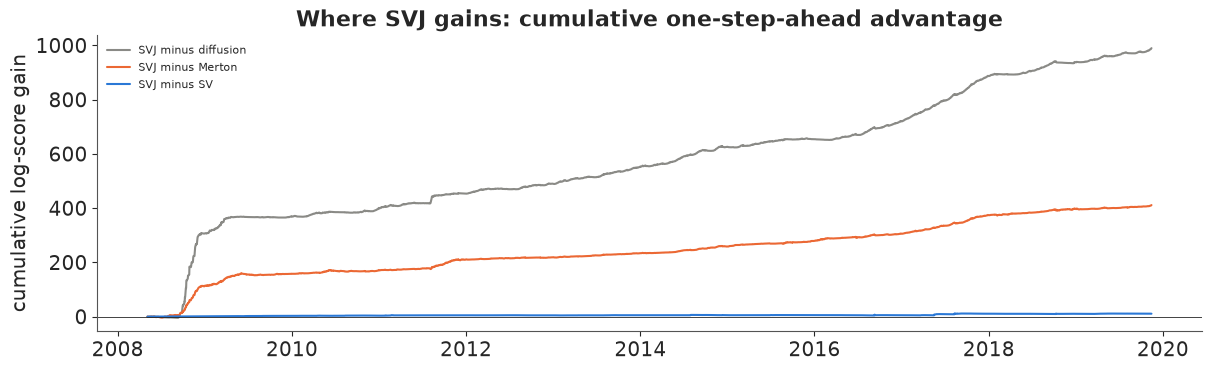

In [8]:
def draws(idata, names, n=40, seed=0):
    post = idata.posterior.to_dataset()[names].stack(sample=("chain", "draw"))
    idx = np.random.default_rng(seed).choice(post.sizes["sample"], n, replace=False)
    return {k: post[k].values[..., idx] for k in names}


def prequential_sv(par, jumps, n_particles=2000, seed=0):
    """(draws, T) one-step log predictive densities for SV / SVJ via a bootstrap particle filter."""
    rr = np.random.default_rng(seed)
    D = len(par["mu"])
    mu, hb, ph, sh = (par[k][:, None] for k in ["mu", "h_bar", "phi", "s_h"])
    h = hb + sh / np.sqrt(1 - ph**2) * rr.standard_normal((D, n_particles))
    out = np.empty((D, T))
    for t in range(T):
        if t > 0:
            h = hb + ph * (h - hb) + sh * rr.standard_normal((D, n_particles))
        vol = np.exp(h / 2)
        logl = stats.norm.logpdf(r[t], mu, vol)
        if jumps:
            p, mj, sj = (par[k][:, None] for k in ["p_jump", "mu_j", "sigma_j"])
            logl = np.logaddexp(np.log1p(-p) + logl,
                                np.log(p) + stats.norm.logpdf(r[t], mu + mj, np.sqrt(vol**2 + sj**2)))
        out[:, t] = logsumexp(logl, axis=1) - np.log(n_particles)
        w = np.exp(logl - logl.max(axis=1, keepdims=True))
        w /= w.sum(axis=1, keepdims=True)
        # systematic resampling, one row per posterior draw
        offset = np.arange(D)[:, None]
        cum = np.cumsum(w, axis=1)
        cum[:, -1] = 1.0
        u = (rr.random((D, 1)) + np.arange(n_particles)) / n_particles
        idx = np.searchsorted((cum + offset).ravel(), (u + offset).ravel()).reshape(D, n_particles)
        h = h.ravel()[np.minimum(idx, D * n_particles - 1)].reshape(D, n_particles)
    return out


t0 = time.time()
lpd = {}
lpd["diffusion"] = stats.norm.logpdf(r, r.mean(), r.std())[None, :]
pm_ = draws(fits["Merton"], ["mu", "sigma", "lam", "mu_j", "sigma_j"])
comp = (stats.poisson.logpmf(n_jumps[:, None, None], pm_["lam"][None, :, None])
        + stats.norm.logpdf(r[None, None, :], pm_["mu"][None, :, None] + n_jumps[:, None, None] * pm_["mu_j"][None, :, None],
                            np.sqrt(pm_["sigma"][None, :, None] ** 2 + n_jumps[:, None, None] * pm_["sigma_j"][None, :, None] ** 2)))
lpd["Merton"] = logsumexp(comp, axis=0)
lpd["SV"] = prequential_sv(draws(fits["SV"], ["mu", "h_bar", "phi", "s_h"]), jumps=False)
lpd["SVJ"] = prequential_sv(draws(fits["SVJ"], ["mu", "h_bar", "phi", "s_h", "p_jump", "mu_j", "sigma_j"]), jumps=True)
print(f"particle filters: {time.time() - t0:.0f} s")
daily = {k: logsumexp(v, axis=0) - np.log(len(v)) for k, v in lpd.items()}   # average over draws
for k, v in daily.items():
    print(f"{k:<10} one-step log score {v.sum():8.1f}   difference from SVJ {v.sum() - daily['SVJ'].sum():8.1f} "
          f"(se {np.sqrt(T) * (v - daily['SVJ']).std():.1f})")

fig, ax = plt.subplots(figsize=(12, 3.6))
for k in ["diffusion", "Merton", "SV"]:
    ax.plot(dates, np.cumsum(daily["SVJ"] - daily[k]), color=MODEL_COLOURS[k], label=f"SVJ minus {k}")
ax.axhline(0, color=INK, lw=0.6)
ax.set(ylabel="cumulative log-score gain", title="Where SVJ gains: cumulative one-step-ahead advantage")
ax.legend(fontsize=8);

Two thousand particles are plenty for a one-dimensional state (the log scores barely change
with more), and the conclusions are large compared with their standard errors:

- **Volatility clustering is the big effect.** Both SV models beat the constant-volatility
  models by hundreds of nats; the Merton model's frequent "jumps" improve on the normal
  diffusion but come nowhere near a model whose volatility moves.
- **Jumps on top of SV are a small improvement, and not a decisive one.** SVJ beats SV by about
  11 nats over 2,905 days, about 1.5 standard errors. The small steps in the SVJ-minus-SV curve
  fall on the calm-period jump days of section 4: when volatility is low, a 2% move costs SV
  more than SVJ. On every other day the two predict the same. The data favour jumps a little;
  they do not demand them.
- Almost all of the gains over the constant-volatility models are made in the autumn of 2008,
  when volatility jumped from about 1% to 5% a day: the rest of the period adds steadily but
  slowly.

## 6 · Decisions: crash risk and the volatility smile

**Crash risk.** What is the probability of at least one day with a loss of 5% or more in the
252 trading days after the data end (14 November 2019, a calm market)? We simulate a year
forward from each posterior draw, starting SV and SVJ from their filtered volatility at the end
of the sample.

In [9]:
def crash_probability(name, n=2000, horizon=252, threshold=-5.0, seed=0):
    rr = np.random.default_rng(seed)
    if name == "diffusion":
        sims = rr.normal(r.mean(), r.std(), (n, horizon))
    elif name == "Merton":
        par = draws(fits["Merton"], ["mu", "sigma", "lam", "mu_j", "sigma_j"], n=n, seed=seed)
        k = rr.poisson(par["lam"][:, None], (n, horizon))
        sims = (par["mu"][:, None] + par["sigma"][:, None] * rr.standard_normal((n, horizon))
                + k * par["mu_j"][:, None] + np.sqrt(k) * par["sigma_j"][:, None] * rr.standard_normal((n, horizon)))
    else:
        names = ["mu", "h_bar", "phi", "s_h", "h"] + (["p_jump", "mu_j", "sigma_j"] if name == "SVJ" else [])
        post = fits[name].posterior.to_dataset()
        post = post.assign(h=post["h"].isel(h_dim_0=-1))
        par = draws(fits[name], [v for v in names if v != "h"], n=n, seed=seed)
        stacked = post["h"].stack(sample=("chain", "draw")).values
        h = stacked[np.random.default_rng(seed).choice(stacked.size, n, replace=False)]
        sims = np.empty((n, horizon))
        for t in range(horizon):
            h = par["h_bar"] + par["phi"] * (h - par["h_bar"]) + par["s_h"] * rr.standard_normal(n)
            sims[:, t] = par["mu"] + np.exp(h / 2) * rr.standard_normal(n)
            if name == "SVJ":
                jump = rr.random(n) < par["p_jump"]
                sims[:, t] += jump * (par["mu_j"] + par["sigma_j"] * rr.standard_normal(n))
    return np.mean((sims <= threshold).any(axis=1)), sims


crash = {name: crash_probability(name) for name in ["diffusion", "Merton", "SV", "SVJ"]}
hist_rate = np.mean([(r[i:i + 252] <= -5).any() for i in range(0, T - 252, 21)])
for name, (p, _) in crash.items():
    print(f"{name:<10} P(at least one day <= -5% in the next year) = {p:.3f}")
print(f"historical share of 252-day windows in 2008-2019 with such a day: {hist_rate:.2f}")

diffusion  P(at least one day <= -5% in the next year) = 0.006
Merton     P(at least one day <= -5% in the next year) = 0.543
SV         P(at least one day <= -5% in the next year) = 0.231
SVJ        P(at least one day <= -5% in the next year) = 0.200
historical share of 252-day windows in 2008-2019 with such a day: 0.17


The models' answers differ by two orders of magnitude, from the same data. The
constant-volatility diffusion says a -5% day is essentially impossible (0.6%). The Merton model,
whose frequent jumps give every day the same heavy tail, puts it above 50%, far above the
historical frequency of 17% of 252-day windows in this period. The SV models give about 20-23%,
close to the historical rate - even though they start from the calm market of November 2019.
A calm start does not make a crash day impossible within a year, because volatility can
build up over weeks (persistence $\phi \approx 0.98$, volatility of volatility $s_h \approx
0.26$) and a -5% day then needs only a two- or three-sigma move. SVJ's small jumps barely change
the answer (they are too small to produce a -5% day on their own).

(For the record: the S&P 500 fell by more than 5% on several days in March 2020, four months
after these data end. The SV models gave such a day within the year a probability of about one
in five; the constant-volatility diffusion gave it about one in 170.)

**The volatility smile.** Option markets price exactly this kind of risk. In the Merton model a
European option has a closed form: a Poisson-weighted sum of Black-Scholes prices (Merton
1976). Converting prices back to Black-Scholes implied volatilities gives the **smile**: out-of
-the-money puts (low strikes) are more expensive than a normal model says, because jumps put
more mass in the left tail. We compute it for one-month options from posterior draws of the
Merton model *and* from a Merton model with SVJ's rare jumps and the November 2019 volatility.
(This uses the fitted real-world parameters as if they were risk-neutral: it ignores the risk
premia that make real option smiles steeper. It illustrates the shape, not market prices.)

implied vol at strikes 0.85 / 1.00 / 1.10 (posterior median, % per year):
  Merton (constant volatility, frequent jumps)   20.6 / 18.7 / 18.7
  SVJ jumps at the Nov 2019 volatility           9.2 / 6.9 / 6.4


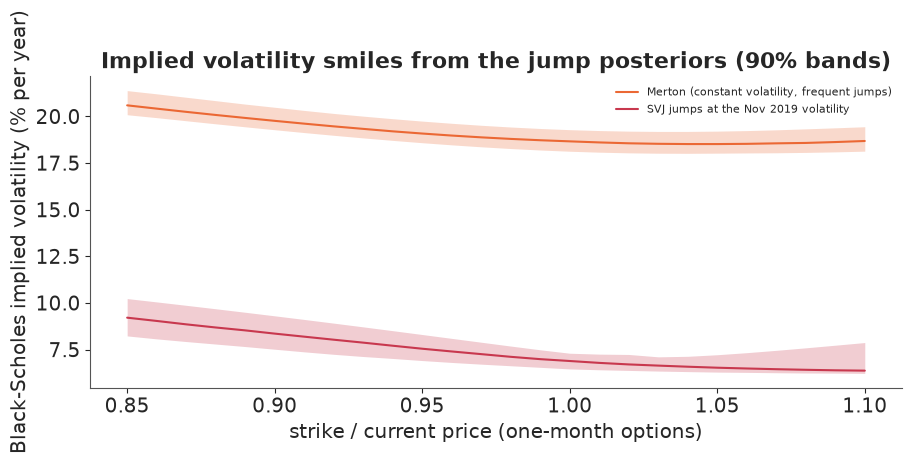

In [10]:
def bs_call(S, K, T_, sig):
    d1 = (np.log(S / K) + 0.5 * sig**2 * T_) / (sig * np.sqrt(T_))
    return S * stats.norm.cdf(d1) - K * stats.norm.cdf(d1 - sig * np.sqrt(T_))


def merton_call(S, K, T_, sig, lam, mu_j, sig_j, n_max=40):
    """Merton (1976) price with zero rates; jump sizes in log terms (fractions, not %).

    Conditional on n jumps the price is Black-Scholes with forward F_n and volatility sigma_n;
    weighting by Poisson(lam T) keeps the forward a martingale (sum_n w_n F_n = S).
    """
    k = np.exp(mu_j + 0.5 * sig_j**2) - 1                  # mean relative jump size
    price = 0.0
    for n in range(n_max):
        sig_n = np.sqrt(sig**2 + n * sig_j**2 / T_)
        f_n = S * np.exp(n * (mu_j + 0.5 * sig_j**2) - lam * k * T_)
        price += stats.poisson.pmf(n, lam * T_) * bs_call(f_n, K, T_, sig_n)
    return price


def implied_vol(price, S, K, T_):
    return optimize.brentq(lambda s: bs_call(S, K, T_, s) - price, 1e-4, 5)


strikes = np.linspace(0.85, 1.10, 26)
T_OPT = 21 / 252
m_par = draws(fits["Merton"], ["sigma", "lam", "mu_j", "sigma_j"], n=60, seed=3)
j_par = draws(fits["SVJ"], ["p_jump", "mu_j", "sigma_j"], n=60, seed=3)
vol_now = np.exp(h_svj[-20:] / 2).mean()                  # SVJ volatility, last month of data
smiles = {"Merton (constant volatility, frequent jumps)": [], "SVJ jumps at the Nov 2019 volatility": []}
for i in range(60):
    for label, (sig_d, lam_d, mj, sj) in [
        ("Merton (constant volatility, frequent jumps)",
         (m_par["sigma"][i], m_par["lam"][i], m_par["mu_j"][i], m_par["sigma_j"][i])),
        ("SVJ jumps at the Nov 2019 volatility",
         (vol_now, j_par["p_jump"][i], j_par["mu_j"][i], j_par["sigma_j"][i]))]:
        sig, lam_a, mj_a, sj_a = sig_d / 100 * np.sqrt(252), lam_d * 252, mj / 100, sj / 100
        prices = [merton_call(1.0, K, T_OPT, sig, lam_a, mj_a, sj_a) for K in strikes]
        smiles[label].append([implied_vol(p, 1.0, K, T_OPT) for p, K in zip(prices, strikes)])

fig, ax = plt.subplots(figsize=(9, 4))
for (label, iv), c in zip(smiles.items(), [ORANGE, RED]):
    iv = 100 * np.array(iv)
    q = np.quantile(iv, [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(strikes, q[0], q[2], color=c, alpha=0.25, lw=0)
    ax.plot(strikes, q[1], color=c, label=label)
ax.set(xlabel="strike / current price (one-month options)", ylabel="Black-Scholes implied volatility (% per year)",
       title="Implied volatility smiles from the jump posteriors (90% bands)")
ax.legend(fontsize=8);
print("implied vol at strikes 0.85 / 1.00 / 1.10 (posterior median, % per year):")
for label, iv in smiles.items():
    med = np.median(100 * np.array(iv), axis=0)
    print(f"  {label:<46} {med[0]:.1f} / {med[np.argmin(np.abs(strikes - 1))]:.1f} / {med[-1]:.1f}")

Both posteriors produce a smile tilted to the left: out-of-the-money puts (low strikes) cost
more in volatility terms than at-the-money options, because negative jumps add mass to the left
tail. The two models tell different stories, though (numbers in the printout). The **Merton**
posterior gives a high, almost flat level (about 19% a year at the money, 21% at the 0.85
strike): its frequent jumps behave like extra diffusion, and over a month they average out into
a nearly normal distribution with a slightly heavy left tail. **SVJ's** rare jumps on top of the
calm November 2019 volatility give a low level (about 7% at the money) but a *relatively*
steeper skew, rising by about a third to 9% at the 0.85 strike: when the diffusion is quiet,
a few jumps are a large part of what can go wrong in a month. Real option
markets in late 2019 showed a much steeper skew than either, for two reasons this pricing leaves
out: the risk premium investors pay for crash insurance, and volatility that rises as prices
fall (the leverage effect), which SVJ's latent volatility has but this jump-only formula
ignores. The posterior bands show how much of each curve twelve years of data pin down.

## Summary

- A **jump-diffusion SDE** adds a compound Poisson process to Brownian motion. Its daily
  transition density is a Poisson mixture of normals, so the jump count can be **summed out**
  in PyMC with `logsumexp`, and the posterior probability of a jump on each day comes for free
  (sections 1-2).
- **With constant volatility, "jumps" absorb volatility clustering**: the Merton model finds a
  jump on a third of all days (section 2).
- **With stochastic volatility, jumps become rare and meaningful**: about 2.5% of days, and
  they are moves that are large *relative to the volatility at the time*, mostly in calm
  markets. The 2008 crash days were high-volatility days, not jumps (sections 3-4).
- **Compare time-series models by one-step-ahead predictive scores**, computed for latent-state
  models with a particle filter; volatility clustering is worth hundreds of nats here, jumps on
  top of it about 11 (1.5 standard errors) (section 5).
- **Decisions depend on the model**: the probability of a crash day next year ranges from under
  1% to over 50%, and the implied volatility smile changes shape. Model choice is part of the
  risk (section 6).

## Try it yourself

1. **Jumps in volatility.** Add jumps to $h_t$ as well (the SVCJ model of Eraker, Johannes &
   Polson 2003): with probability $p_v$ the log-variance jumps up by an exponential amount.
   Does it absorb the 2008 and 2020-style volatility bursts better, and what happens to the
   return jumps?
2. **Self-exciting jumps.** Replace the constant jump probability by a Hawkes-type intensity
   that rises after each jump and decays ($p_t = p_0 + \alpha \sum_{s<t} \beta^{t-s} J_s$, with
   the jump indicators summed out by a forward recursion as in E24). Do jumps cluster?
3. **Student-t shocks instead of jumps.** Fit SV with Student-t innovations and compare its
   one-step score with SVJ. Heavy tails and jumps are two answers to the same Q-Q plot: which
   one does the prequential score prefer, and on which days?